# Frisch-Waugh-Lowell theorem

This notebook applies the Frisch-Waugh-Lowell theorem to OLS. Suppose the model is:

$$
y_i = \beta_0 + \beta_1 x_{1,i} + \beta_2 x_{2,i} + \epsilon_i
$$

Our goal is to factor out the effect of $x_{2,i}$.

## 0. Required packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

## 1. Simulate data

We simulate a dataset of 500 observations for $y$, $x_1$ and $x_2$. Suppose the model describes the relationship of returns between a target stock, the market factor and a peer stock (same industry as the target stock). 

$$
r^{target}_t = \beta_0 + \beta_{mkt} mkt_t + \beta_{peer} r^{peer}_t + \epsilon_t
$$

We impose some correlation between the peer stock and the market, and the target and peer stock.

The seed is useful for repricability

In [2]:
# -----------------------------
# Settings
# -----------------------------
np.random.seed(42)
n = 500

# x2 = market factor
mkt = np.random.normal(0, 1, n)

# x1 = "peer stock" return, correlated with the market
peer = 3 * mkt + np.random.normal(0, 0.6, n)

# y = target stock return, depends on both peer and market
y = 0.0 + 0.7 * peer + 2 * mkt + np.random.normal(0, 0.8, n)

## 2. Regression

We first regresss the full model and plot the relationship between the target and peer stock, intentionally excluding the market excess returns.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     6057.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:21:56   Log-Likelihood:                -600.36
No. Observations:                 500   AIC:                             1207.
Df Residuals:                     497   BIC:                             1219.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0852      0.036      2.361      0.0

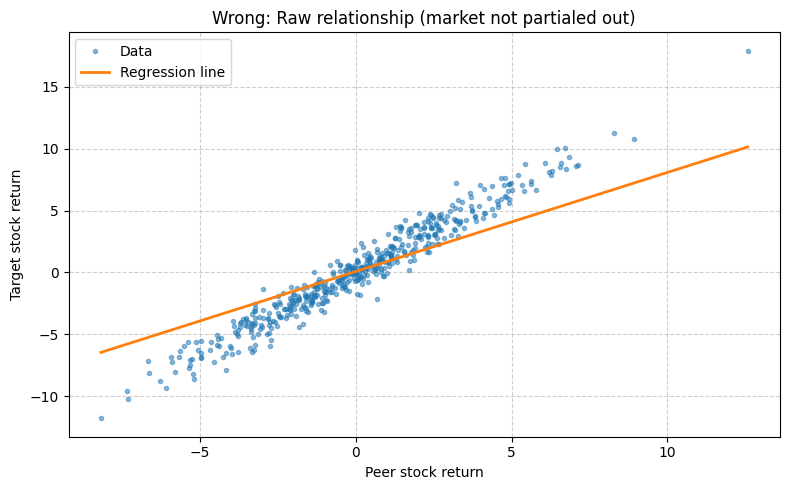

In [3]:

# -----------------------------
# 1) Full regression
# -----------------------------
X = sm.add_constant(np.column_stack([peer, mkt]))
model = sm.OLS(y, X).fit()

print(model.summary())

alpha, beta_peer, beta_mkt = model.params


# -----------------------------
# Plot style
# -----------------------------
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.6
})


# -----------------------------
# 2) WRONG plot
# -----------------------------
x_raw = peer
y_raw = y

x_grid = np.linspace(x_raw.min(), x_raw.max(), 200)
mkt_mean = mkt.mean()

y_line_wrong = alpha + beta_peer * x_grid

plt.figure()
plt.plot(x_raw, y_raw, ".", alpha=0.5, label="Data")
plt.plot(x_grid, y_line_wrong, linewidth=2, label="Regression line")

plt.xlabel("Peer stock return")
plt.ylabel("Target stock return")
plt.title("Wrong: Raw relationship (market not partialed out)")
plt.legend()
plt.tight_layout()
plt.savefig("Ch2_FWL_wrong.png", dpi=300, bbox_inches='tight')

3. Frisch_Waugh-Lowell theorem

We apply the Frisch-Waugh-Lowell theorem to factor out the effect of market excess returns. The key idea is to plot the relationship between the target and peer stock, after controlling for $mkt$. 

We proceed in three steps:
1. Regress the target stock returns on the market and obtain the residual
    $$r^{target}_t = \gamma_0 + 1gamma_1 r^{mkt}_t + \omega_t \rightarrow \hat{u}^{target}_t$$
2. Regress the peer stock returns on the market and obtain the residual 
       $$ r^{peer}_t = \alpha_0 + \alpha_1 r^{mkt}_t + \eta_t \rightarrow \hat{u}^{peer}_t$$ 
3. Regress the target stock residual on the peer stock residuals
       u^{target}_t = \tilde{\beta}_{peer} u^{peer}_t + zeta_t


Notice that $ \tilde{\beta}_{peer}= \beta_{peer}$

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     168.2
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.43e-33
Time:                        13:22:19   Log-Likelihood:                -600.36
No. Observations:                 500   AIC:                             1205.
Df Residuals:                     498   BIC:                             1213.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.631e-16      0.036   4.53e-15      1.0

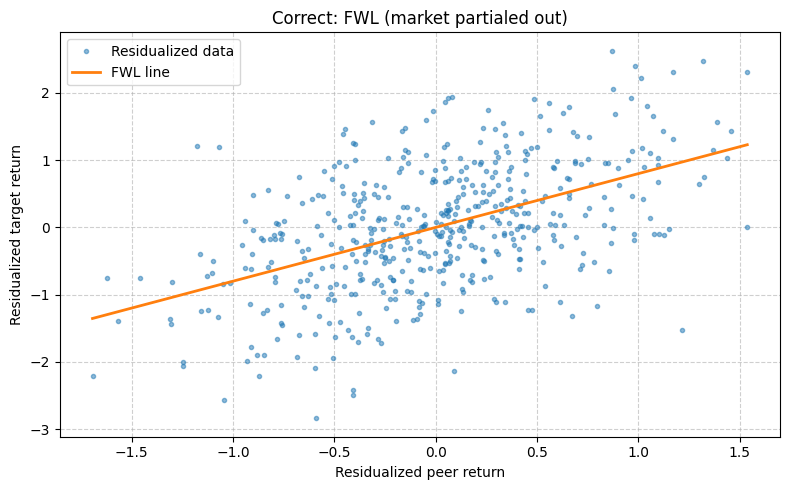

In [4]:

# -----------------------------
# 3) FWL
# -----------------------------
X_mkt = sm.add_constant(mkt)

y_resid = sm.OLS(y, X_mkt).fit().resid
peer_resid = sm.OLS(peer, X_mkt).fit().resid

fwl_model = sm.OLS(y_resid, sm.add_constant(peer_resid)).fit()
print(fwl_model.summary())


# -----------------------------
# 4) Correct plot
# -----------------------------
x_fwl = peer_resid
y_fwl = y_resid

x_grid_fwl = np.linspace(x_fwl.min(), x_fwl.max(), 200)
y_line_fwl = fwl_model.params[0] + fwl_model.params[1] * x_grid_fwl

plt.figure()
plt.plot(x_fwl, y_fwl, ".", alpha=0.5, label="Residualized data")
plt.plot(x_grid_fwl, y_line_fwl, linewidth=2, label="FWL line")

plt.xlabel("Residualized peer return")
plt.ylabel("Residualized target return")
plt.title("Correct: FWL (market partialed out)")
plt.legend()
plt.tight_layout()
plt.savefig("Ch2_FWL.png", dpi=300, bbox_inches='tight')